In [88]:
#Importações
import pandas as pd
import ast
import unicodedata
import matplotlib.pyplot as plt
import matplotlib.ticker as mt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [2]:
"""Dados json
Nesta etapa estou carregando os dados json"""

clientes_crm= pd.read_json("clientes_crm.json")
custo_importacao= pd.read_json("custos_importacao.json")
#clientes_crm.head()
#custo_importacao.head()

In [3]:
"""dados csv
Nesta carrego os csv"""

produtos= pd.read_csv("produtos_raw.csv")
vendas= pd.read_csv("vendas_2023_2024.csv")
#produtos.head()
#vendas.head()

## Analise da base de cliente e tratamento

In [4]:
#identificando as colunas
clientes_crm.columns

Index(['full_name', 'location', 'code', 'email'], dtype='str')

In [94]:
#nessa celula identifiquei que os nomes das localizações estava sem tratamento e desorganizado
clientes_crm.head
clientes_crm["location"].value_counts()

location
BA - Porto Seguro                 2
Aratu (Candeias) , BA             1
PE , Recife                       1
Rio Grande,RS                     1
AC , Rio Branco                   1
PA - Santarém Novo                1
Fortaleza do Tabocão , TO         1
PB/Cabedelo                       1
SE - Aracaju                      1
PB - João Pessoa                  1
Santarém / PA                     1
TO , Fortaleza do Tabocão         1
PA / Santarém                     1
AM , Itacoatiara                  1
Fortaleza do Tabocão,TO           1
Fortaleza,CE                      1
MS - Corumbá                      1
Santarém - PA                     1
Maceió / AL                       1
PA , Santarém Novo                1
AC,Rio Branco                     1
SE / Aracaju                      1
Santos - SP                       1
Laguna / SC                       1
ES / São Mateus                   1
Manaus/AM                         1
Salvador,BA                       1
PR , Antonina      

In [6]:
#padronização do texto
clientes_crm["location"] = clientes_crm["location"].str.strip()

In [7]:
#extrair estado
clientes_crm["estado"] = clientes_crm["location"].str.extract(r'([A-Z]{2})')

In [8]:
#extrair cidade
clientes_crm["cidade"] = clientes_crm["location"].str.replace(r'[A-Z]{2}', '', regex=True)
clientes_crm["cidade"] = clientes_crm["cidade"].str.replace(r'[-,/()]', '', regex=True).str.strip()

In [95]:
# temos a coluna original location e as que criei apenas com estados e ao lado apenas com a cidade
clientes_crm.head()

,full_name,location,client_id,email,estado,cidade
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com,BA,Aratu Candeias
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com,PE,Recife
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com,RS,Rio Grande
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira#gmail.com,AC,Rio Branco
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas#icloud.com,PA,Santarém Novo


In [10]:
#identificação dos tipos de dados
clientes_crm.dtypes

full_name      str
location       str
code         int64
email          str
estado         str
cidade         str
dtype: object

In [11]:
clientes_crm.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   full_name  49 non-null     str  
 1   location   49 non-null     str  
 2   code       49 non-null     int64
 3   email      49 non-null     str  
 4   estado     49 non-null     str  
 5   cidade     49 non-null     str  
dtypes: int64(1), str(5)
memory usage: 2.4 KB


In [12]:
clientes_crm.isnull().sum()

full_name    0
location     0
code         0
email        0
estado       0
cidade       0
dtype: int64

In [13]:
clientes_crm.duplicated().sum()

np.int64(0)

In [14]:
clientes_crm = clientes_crm.rename(columns={"code": "client_id"})
clientes_crm.head()

,full_name,location,client_id,email,estado,cidade
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com,BA,Aratu Candeias
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com,PE,Recife
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com,RS,Rio Grande
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira#gmail.com,AC,Rio Branco
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas#icloud.com,PA,Santarém Novo


## Tratamento base de clientes -- localidade

A coluna `location` apresentava formatos inconsistentes, com variações
na forma de representação de cidade e estado.

Foi realizada a extração das informações de estado e cidade, permitindo
padronização e facilitando análises geográficas futuras, mantive os dados brutos
de location.

durante a exploração de dados conclui-se que a base de dados de clientes não existe nulos e duplicatas

## Analise da base de custo de importação

In [15]:
#identificando as colunas
custo_importacao.columns

Index(['product_id', 'product_name', 'category', 'historic_data'], dtype='str')

In [16]:
#identificação dos tipos de dados
#obs: historic_data esta como object e vai ser tratada
custo_importacao.dtypes

product_id        int64
product_name        str
category            str
historic_data    object
dtype: object

In [17]:
custo_importacao.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     150 non-null    int64 
 1   product_name   150 non-null    str   
 2   category       150 non-null    str   
 3   historic_data  150 non-null    object
dtypes: int64(1), object(1), str(2)
memory usage: 4.8+ KB


In [18]:
#identificação de nulos
custo_importacao.isnull().sum()

product_id       0
product_name     0
category         0
historic_data    0
dtype: int64

In [19]:
#tratamento do campo historic_data
custo_importacao["historic_data"] = custo_importacao["historic_data"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [20]:
custo_importacao = custo_importacao.explode("historic_data")

In [21]:
historic_df = pd.json_normalize(custo_importacao["historic_data"])

In [22]:
custo_importacao_tratado = pd.concat(
    [custo_importacao.drop(columns=["historic_data"]), historic_df],
    axis=1
)

In [23]:
custo_importacao_tratado.head()


,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,25/09/2018,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,19/03/2019,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,17/01/2020,7918.18


In [24]:
custo_importacao_tratado["start_date"] = pd.to_datetime(
    custo_importacao_tratado["start_date"], 
    dayfirst=True,
    errors="coerce"
)

In [25]:
#separação das tabelas de custo historico e custo final
custo_historico = custo_importacao_tratado.copy()

custo_final = (
    custo_importacao_tratado
    .sort_values("start_date")
    .groupby("product_id")
    .tail(1)
)

In [26]:
custo_historico ["category"].value_counts()

category
eletrônicos    436
ancoragem      413
propulsão      411
Name: count, dtype: int64

In [27]:
custo_final["category"].value_counts()

category
ancoragem      50
eletrônicos    50
propulsão      50
Name: count, dtype: int64

In [28]:
custo_final.head()

,product_id,product_name,category,start_date,usd_price
103,104,Cabo de Nylon Delta Zen Vortex Storm,ancoragem,2020-03-26,742.54
38,39,GPS Furuno Vector,eletrônicos,2020-10-16,5270.87
125,126,Corrente Danforth Hydro,ancoragem,2020-10-28,467.05
138,139,Boia de Arqueamento Danforth Torque,ancoragem,2020-10-30,246.89
53,54,Motor de Popa Yamaha Evo Dash 155HP,propulsão,2021-08-06,23191.90


In [29]:
custo_final.dtypes

product_id               int64
product_name               str
category                   str
start_date      datetime64[us]
usd_price              float64
dtype: object

In [32]:
custo_historico.isnull()

,product_id,product_name,category,start_date,usd_price
0,False,False,False,False,False
0,False,False,False,False,False
0,False,False,False,False,False
0,False,False,False,False,False
0,False,False,False,False,False
...,...,...,...,...,...
149,False,False,False,False,False
149,False,False,False,False,False
149,False,False,False,False,False
149,False,False,False,False,False


In [33]:
custo_final.info()

<class 'pandas.DataFrame'>
Index: 150 entries, 103 to 24
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    150 non-null    int64         
 1   product_name  150 non-null    str           
 2   category      150 non-null    str           
 3   start_date    150 non-null    datetime64[us]
 4   usd_price     150 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 7.0 KB


In [34]:
custo_historico.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,7918.18


 
## Tratamento da coluna historic_data e conclusão da base de importação
Foi identificado que a coluna `historic_data` continha listas de registros
históricos de preços em formato JSON.

Para permitir a análise temporal dos custos, os dados foram:

1. Convertidos de string para estrutura de lista
2. Expandido para múltiplas linhas (uma por registro histórico)
3. Normalizados em colunas estruturadas

Após a normalização da coluna `historic_data`, observou-se um aumento no número
de linhas devido à existência de múltiplos registros históricos por produto.
A tabela custo_historico será usada para possiveis analises temporais

Para a análise principal, foi considerada a versão mais recente do custo,
representando o valor atual de importação, representada na tabela Custo_final

Conclui-se que a base de dados de custo importação não apresenta nulos

## Analise da base de produtos

In [35]:
#identificando as colunas
produtos.columns

Index(['name', 'price', 'code', 'actual_category'], dtype='str')

In [36]:
produtos.dtypes

name                 str
price                str
code               int64
actual_category      str
dtype: object

In [37]:
#padronizar as categorias atuais
#preço esta como str colocar como numeric
produtos.head()

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz


In [38]:
#corrigindo variações da categoria, Padronização
def limpar_texto(texto):
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(c)
    )
    texto = texto.replace(" ", "")
    return texto

produtos["actual_category"] = produtos["actual_category"].apply(limpar_texto)

In [39]:
produtos.head(100)

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,eletronicos
1,Transponder Furuno Marlin,R$ 13998.15,2,eletronicos
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,eletronicos
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,eletronicoz
...,...,...,...,...
95,Motor Elétrico Yamaha Nautic Kraken 133HP,R$ 88854.1,92,propucao
96,Motor Elétrico Yamaha Flow 204HP,R$ 100477.01,93,propulsao
97,Motor de Popa Volvo Magnum 276HP,R$ 40750.84,94,propucao
98,Motor Diesel Honda Leviathan 133HP,R$ 69808.04,95,propulsao


In [40]:
# substituindo as categorias
mapa = {
    "eletroniscos": "eletrônicos",
    "eletronicoz" : "eletrônicos",
    "eletrunicos": "eletrônicos",
    "eletronicos": "eletrônicos",
    "prop": "propulsão",
    "propulsao": "propulsão",
    "propulcao": "propulsão",
    "propulsam": "propulsão",
    "propucao" : "propulsão",
    "propulssao" : "propulsão",
    "ancorajem": "ancoragem",
    "ancoragen": "ancoragem",
    "encoragem": "ancoragem",
    "encoragi": "ancoragem",
    "ancorajm": "ancoragem",
    "ancorajen": "ancoragem",
    "ancoraguem": "ancoragem"
}

produtos["actual_category"] = produtos["actual_category"].replace(mapa)

In [41]:
produtos["actual_category"].value_counts()

actual_category
propulsão      53
ancoragem      53
eletrônicos    51
Name: count, dtype: int64

In [42]:
# corrigindo o tipo de dado
produtos["price"] = (
    produtos["price"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .astype(float)
)

In [43]:
produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             157 non-null    str    
 1   price            157 non-null    float64
 2   code             157 non-null    int64  
 3   actual_category  157 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 KB


In [44]:
produtos.isnull().sum()

name               0
price              0
code               0
actual_category    0
dtype: int64

In [45]:
produtos.duplicated().sum()

np.int64(7)

In [46]:
produtos = produtos.rename(columns={"code": "product_id"})
produtos.head()

,name,price,product_id,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,eletrônicos
1,Transponder Furuno Marlin,13998.15,2,eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,eletrônicos


## Padronização de categorias

Foram identificadas diversas inconsistências na coluna `actual_category`,
incluindo variações de acentuação, espaçamento e erros de digitação.

Foi aplicada uma função de limpeza para normalizar os textos, incluindo:

- conversão para minúsculas
- remoção de acentos
- remoção de espaços

Em seguida, foi criado um mapeamento manual para corrigir variações
identificadas, consolidando as categorias em valores únicos e consistentes.
Outros passos incluem a verificação de nulos nas quais não temos nulos e verificação de duplicatas

## Analise da base de vendas

In [47]:
#verificando as colunas
vendas.columns

Index(['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date'], dtype='str')

In [48]:
#verificando os tipos de dados
# sales_dates deve ser convertido para Date
vendas.dtypes

id              int64
id_client       int64
id_product      int64
qtd             int64
total         float64
sale_date         str
dtype: object

In [49]:
vendas[vendas["sale_date"].isnull()]

,id,id_client,id_product,qtd,total,sale_date


In [50]:
vendas.head(100)

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
...,...,...,...,...,...,...
95,98,21,142,2,1570.35,2024-02-13
96,99,49,81,9,1099336.00,06-01-2024
97,100,22,93,4,381812.60,21-01-2023
98,101,11,47,8,48984.00,04-07-2024


In [51]:
# transformando o tipo de data
vendas["sale_date"] = pd.to_datetime(
    vendas["sale_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [52]:
vendas["sale_date"].isnull().sum()

np.int64(0)

In [53]:
vendas.duplicated().sum()

np.int64(0)

In [54]:
vendas.dtypes

id                     int64
id_client              int64
id_product             int64
qtd                    int64
total                float64
sale_date     datetime64[us]
dtype: object

In [55]:
vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-10-09
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-03-02
4,5,8,57,4,451403.9,2024-12-02


Conclui-se que nesta base não exite nulos ou duplicatas
## Tratamento da base de vendas - coluna de datas inconsistentes
durante a identificação dos tipos de dados o campo sale_date estava como string
e que possuía formatos mistos de data, incluindo padrões ISO (YYYY-MM-DD) e brasileiro (DD-MM-YYYY).

Para garantir a correta interpretação, foi utilizada a conversão com
`format="mixed"` e `dayfirst=True`, permitindo o tratamento adequado
dos diferentes formatos presentes na base.
durante a exploração dos dados verifiquei os se existe dados nulos e ou duplicatas
e não existem.


## Criando a Tabela analitica

In [56]:
#fazendo a ligação das tabelas pelo seus identificadores e criando a tabela analitica
df_analitico = vendas.merge(produtos, left_on="id_product", right_on="product_id", how="left")

df_analitico = df_analitico.merge(clientes_crm, left_on="id_client", right_on="client_id", how="left")

df_analitico = df_analitico.merge(custo_final[["product_id", "usd_price"]], on="product_id", how="left")

In [57]:
df_analitico.head(2)

,id,id_client,id_product,qtd,total,sale_date,name,price,product_id,actual_category,full_name,location,client_id,email,estado,cidade,usd_price
0,0,42,105,11,3405.0,2023-10-09,Cabo de Nylon Danforth Prime,309.54,105,ancoragem,Márcia Figueiredo,Vila do Conde (Barcarena) - PA,42,márcia.figueiredo#protonmail.com,PA,Vila do Conde Barcarena,53.37
1,1,3,136,9,16873.9,2024-09-15,Cabo de Nylon Bruce Flux Hydro,1973.50,136,ancoragem,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com,RS,Rio Grande,390.62


In [58]:
df_analitico = df_analitico.drop(columns=["product_id"])

In [59]:
df_analitico.shape

(10364, 16)

In [60]:
df_analitico.isnull().sum()

id                 0
id_client          0
id_product         0
qtd                0
total              0
sale_date          0
name               0
price              0
actual_category    0
full_name          0
location           0
client_id          0
email              0
estado             0
cidade             0
usd_price          0
dtype: int64

In [61]:
df_analitico.head()

,id,id_client,id_product,qtd,total,sale_date,name,price,actual_category,full_name,location,client_id,email,estado,cidade,usd_price
0,0,42,105,11,3405.0,2023-10-09,Cabo de Nylon Danforth Prime,309.54,ancoragem,Márcia Figueiredo,Vila do Conde (Barcarena) - PA,42,márcia.figueiredo#protonmail.com,PA,Vila do Conde Barcarena,53.37
1,1,3,136,9,16873.9,2024-09-15,Cabo de Nylon Bruce Flux Hydro,1973.50,ancoragem,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com,RS,Rio Grande,390.62
2,2,25,139,7,9475.3,2024-08-13,Boia de Arqueamento Danforth Torque,1424.88,ancoragem,Femininos Antunes Lopes Ribeiro Amaral,ES / São Mateus,25,femininos.antunes.amaral.lopes.ribeiro@icloud.com,ES,São Mateus,246.89
3,4,20,23,5,55893.0,2023-03-02,Piloto Automático Furuno Torque Peak,11178.63,eletrônicos,Bruno Silva,"PA , Santarém Novo",20,silva.bruno@zoho.com,PA,Santarém Novo,2244.66
4,5,8,57,4,451403.9,2024-12-02,Motor de Popa Honda Vector Kinetic 174HP,118790.57,propulsão,Luiz Alves Pimentel,SE - Aracaju,8,pimentel.alves.luiz#outlook.com,SE,Aracaju,20486.78


## Validação da base integrada

Após a junção das tabelas, foi realizada a validação da base final,
verificando a quantidade de registros e possíveis valores nulos
gerados durante o processo de merge.


## Criando as métricas


In [62]:
cambio_anual = {2023: 4.99, 2024: 5.39}  # câmbio médio anual BCB

In [63]:
df_analitico['ano']            = df_analitico['sale_date'].dt.year
df_analitico['cambio']         = df_analitico['ano'].map(cambio_anual)

In [64]:
df_analitico["preco_unitario"] = df_analitico["total"] / df_analitico["qtd"]
df_analitico['custo_brl']      = df_analitico["usd_price"] * df_analitico["cambio"]
df_analitico["lucro_unitario"] = df_analitico["preco_unitario"] - df_analitico["custo_brl"]
df_analitico["lucro_total"] = df_analitico["lucro_unitario"] * df_analitico["qtd"]
df_analitico["margem_pct"] = (df_analitico["lucro_unitario"] / df_analitico["preco_unitario"]) * 100


Foram criadas métricas derivadas para análise de performance:
foi criado também o cambio anual, para aplicar em custo_brl

- Preço unitário
- Lucro unitário
- Lucro total
- Margem por porcetagem

Essas métricas permitem avaliar a rentabilidade das operações.

In [65]:
df_analitico.dtypes

id                          int64
id_client                   int64
id_product                  int64
qtd                         int64
total                     float64
sale_date          datetime64[us]
name                          str
price                     float64
actual_category               str
full_name                     str
location                      str
client_id                   int64
email                         str
estado                        str
cidade                        str
usd_price                 float64
ano                         int32
cambio                    float64
preco_unitario            float64
custo_brl                 float64
lucro_unitario            float64
lucro_total               float64
margem_pct                float64
dtype: object

In [66]:
df_analitico.head(2)

,id,id_client,id_product,qtd,total,sale_date,name,price,actual_category,full_name,...,estado,cidade,usd_price,ano,cambio,preco_unitario,custo_brl,lucro_unitario,lucro_total,margem_pct
0,0,42,105,11,3405.0,2023-10-09,Cabo de Nylon Danforth Prime,309.54,ancoragem,Márcia Figueiredo,...,PA,Vila do Conde Barcarena,53.37,2023,4.99,309.545455,266.3163,43.229155,475.5207,13.965366
1,1,3,136,9,16873.9,2024-09-15,Cabo de Nylon Bruce Flux Hydro,1973.50,ancoragem,Daniel Farias Ribeiro Teixeira,...,RS,Rio Grande,390.62,2024,5.39,1874.877778,2105.4418,-230.564022,-2075.0762,-12.297549


## analises

In [67]:
#produtos com prejuizo
df_analitico.groupby("name")["lucro_total"].sum().sort_values().head(2)

name
Motor Diesel Yanmar Velocity 37HP             -8.572839e+06
Motor Elétrico Tohatsu Zenith Oceanic 113HP   -5.929223e+06
Name: lucro_total, dtype: float64

In [68]:
top_produtos = df_analitico.groupby("name")["lucro_total"].sum().sort_values(ascending=False)
top_produtos.head(10)

name
Motor Diesel Parsun Velocity Abyss Orca 235HP           6.898966e+06
Motor Elétrico Honda Flux Ultra 273HP                   6.709743e+06
Motor de Popa Volvo Hydro Dash 256HP                    6.073140e+06
Motor Diesel Yanmar Hydro Magnum Boost 267HP            4.649250e+06
Motor Elétrico Torqeedo Pulse 300HP                     4.121668e+06
Motor Elétrico Yamaha Swift Drift Current 265HP         3.527640e+06
Motor Elétrico Torqeedo Ion Orca Vox 186HP              3.483965e+06
Motor Elétrico Torqeedo Barracuda Magnum Helix 101HP    3.479741e+06
Motor de Popa Honda Vector Kinetic 174HP                3.150987e+06
Motor de Popa Parsun Impulse 162HP                      2.852303e+06
Name: lucro_total, dtype: float64

In [69]:
# clientes mais importantes
df_analitico.groupby("id_client")["lucro_total"].sum().sort_values(ascending=False).head(10)

id_client
15    1.960191e+06
1     1.866650e+06
25    1.833569e+06
5     1.825141e+06
45    1.695134e+06
2     1.618571e+06
9     1.583044e+06
49    1.558440e+06
27    1.490994e+06
26    1.476740e+06
Name: lucro_total, dtype: float64

In [70]:
#categorias
df_analitico.groupby("actual_category")["lucro_total"].sum()

actual_category
ancoragem      1.821968e+06
eletrônicos    1.110472e+07
propulsão      3.517711e+07
Name: lucro_total, dtype: float64

## Vizualização

In [73]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

COR_LUCRO  = "#1D9E75"
COR_PREJ   = "#D85A30"
COR_NEUTRA = "#185FA5"

def fmt_milhoes(x, _):
    return f"R$ {x:.1f}M"

def fmt_brl(valor):
    return f"R$ {valor:,.0f}".replace(",", ".")

## Análise 1 — Top produtos por lucro e produtos com prejuízo

Comparativo direto entre os produtos mais rentáveis e os que precisam de atenção.

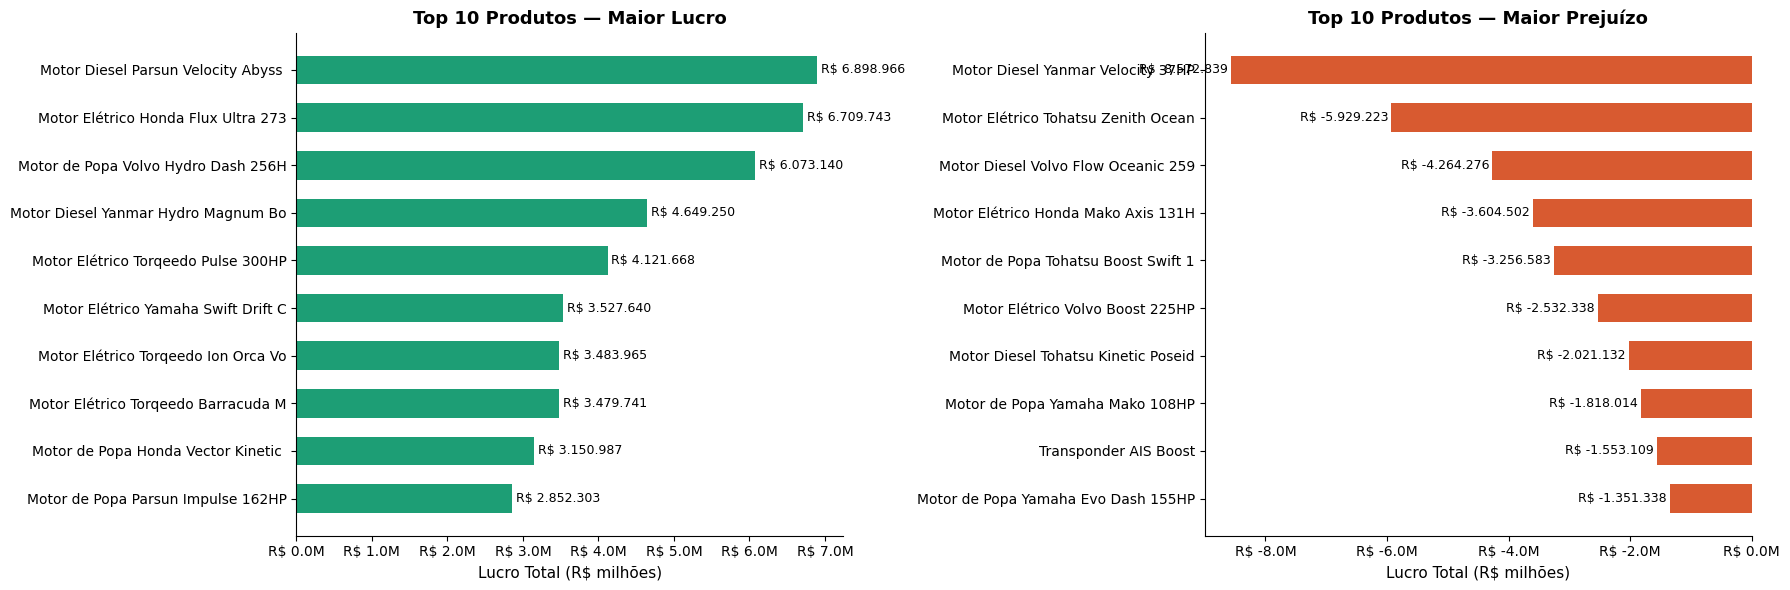

In [76]:
lucro_por_produto = df_analitico.groupby("name")["lucro_total"].sum()

top10_lucro = lucro_por_produto.sort_values(ascending=False).head(10).sort_values()
top10_prej  = lucro_por_produto.sort_values().head(10).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bars = axes[0].barh(
    top10_lucro.index.str[:35],
    top10_lucro.values / 1e6,
    color=COR_LUCRO, edgecolor="none", height=0.6
)
axes[0].set_title("Top 10 Produtos — Maior Lucro")
axes[0].set_xlabel("Lucro Total (R$ milhões)")
axes[0].xaxis.set_major_formatter(mt.FuncFormatter(fmt_milhoes))
for bar, val in zip(bars, top10_lucro.values):
    axes[0].text(val / 1e6 + 0.05, bar.get_y() + bar.get_height() / 2,
                 fmt_brl(val), va="center", fontsize=9)

bars2 = axes[1].barh(
    top10_prej.index.str[:35],
    top10_prej.values / 1e6,
    color=COR_PREJ, edgecolor="none", height=0.6
)
axes[1].set_title("Top 10 Produtos — Maior Prejuízo")
axes[1].set_xlabel("Lucro Total (R$ milhões)")
axes[1].xaxis.set_major_formatter(mt.FuncFormatter(fmt_milhoes))
for bar, val in zip(bars2, top10_prej.values):
    axes[1].text(val / 1e6 - 0.05, bar.get_y() + bar.get_height() / 2,
                 fmt_brl(val), va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

## Análise 2 — Comparativo 2023 vs 2024

Em 2024 a receita cresceu, mas o lucro virou prejuízo.
A alta do câmbio (R$ 4,99 → R$ 5,39) elevou o custo de importação
e comprometeu a margem operacional.

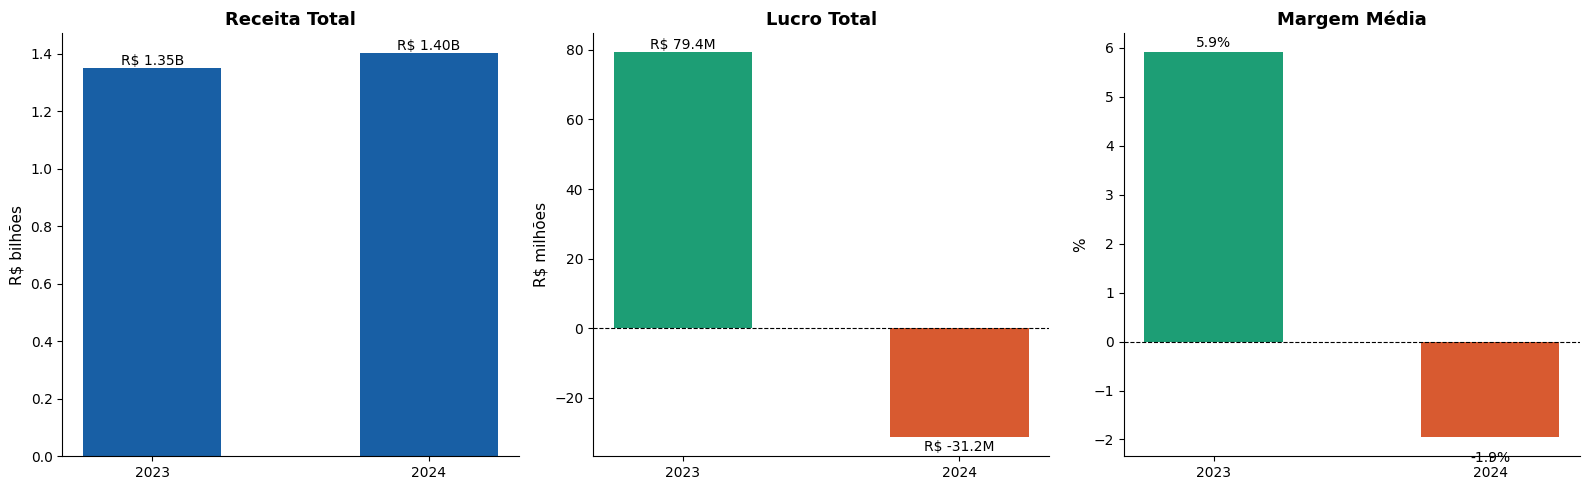

In [78]:
resumo_ano = df_analitico.groupby("ano").agg(
    receita = ("total",       "sum"),
    lucro   = ("lucro_total", "sum"),
    margem  = ("margem_pct",  "mean")
).round(2)

anos = ["2023", "2024"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(anos, resumo_ano["receita"] / 1e9,
            color=[COR_NEUTRA, COR_NEUTRA], edgecolor="none", width=0.5)
axes[0].set_title("Receita Total")
axes[0].set_ylabel("R$ bilhões")
for i, v in enumerate(resumo_ano["receita"]):
    axes[0].text(i, v / 1e9 + 0.01, f"R$ {v/1e9:.2f}B", ha="center", fontsize=10)

cores_lucro = [COR_LUCRO if v >= 0 else COR_PREJ for v in resumo_ano["lucro"]]
axes[1].bar(anos, resumo_ano["lucro"] / 1e6,
            color=cores_lucro, edgecolor="none", width=0.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Lucro Total")
axes[1].set_ylabel("R$ milhões")
for i, v in enumerate(resumo_ano["lucro"]):
    offset = 1 if v >= 0 else -4
    axes[1].text(i, v / 1e6 + offset, f"R$ {v/1e6:.1f}M", ha="center", fontsize=10)

cores_mg = [COR_LUCRO if v >= 0 else COR_PREJ for v in resumo_ano["margem"]]
axes[2].bar(anos, resumo_ano["margem"],
            color=cores_mg, edgecolor="none", width=0.5)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Margem Média")
axes[2].set_ylabel("%")
for i, v in enumerate(resumo_ano["margem"]):
    offset = 0.1 if v >= 0 else -0.5
    axes[2].text(i, v + offset, f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Análise 3 — Evolução mensal do lucro (2023–2024)

A virada de janeiro de 2024 marca o momento em que o câmbio mais alto
começou a impactar as margens mês a mês.

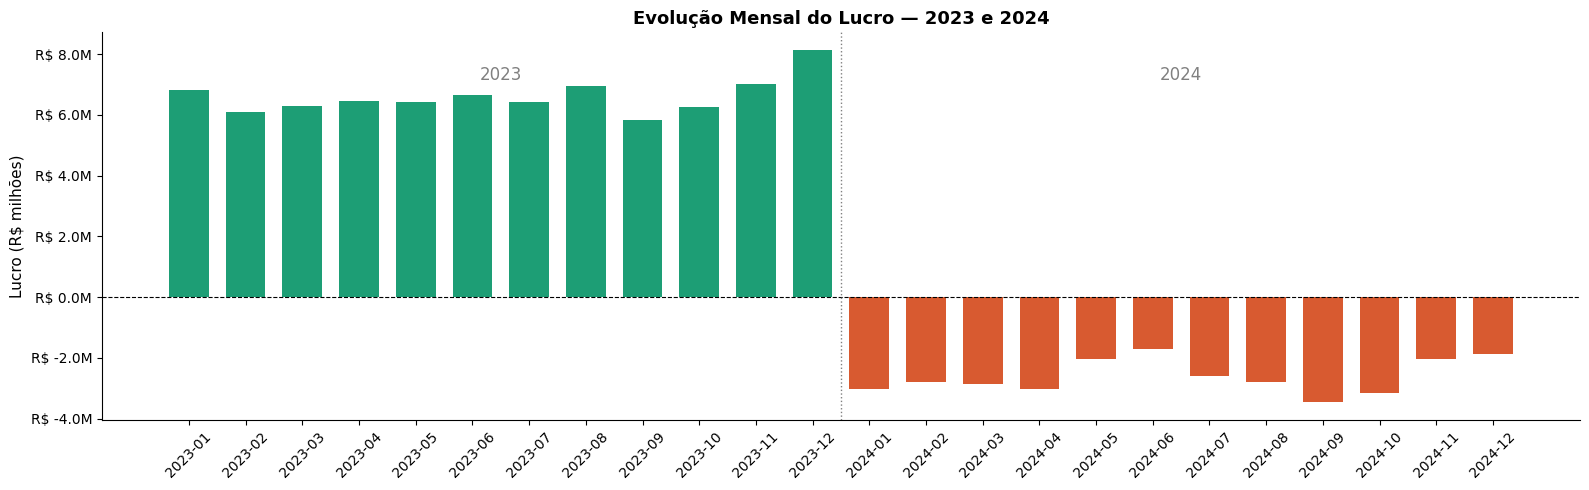

In [81]:
df_analitico["mes"] = df_analitico["sale_date"].dt.to_period("M")
mensal = df_analitico.groupby("mes").agg(
    receita = ("total",       "sum"),
    lucro   = ("lucro_total", "sum")
).reset_index()
mensal["mes_str"] = mensal["mes"].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))

cores_bar = [COR_LUCRO if v >= 0 else COR_PREJ for v in mensal["lucro"]]
ax.bar(mensal["mes_str"], mensal["lucro"] / 1e6,
       color=cores_bar, edgecolor="none", width=0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Evolução Mensal do Lucro — 2023 e 2024")
ax.set_ylabel("Lucro (R$ milhões)")
ax.xaxis.set_tick_params(rotation=45)
ax.yaxis.set_major_formatter(mt.FuncFormatter(fmt_milhoes))
ax.axvline(x=11.5, color="gray", linewidth=1, linestyle=":")
ax.text(5.5,  mensal["lucro"].max() / 1e6 * 0.88, "2023",
        ha="center", fontsize=12, color="gray")
ax.text(17.5, mensal["lucro"].max() / 1e6 * 0.88, "2024",
        ha="center", fontsize=12, color="gray")

plt.tight_layout()
plt.show()

## Análise 4 — Lucro por categoria

Propulsão representa a maior fatia do lucro absoluto,
seguida de eletrônicos e ancoragem.

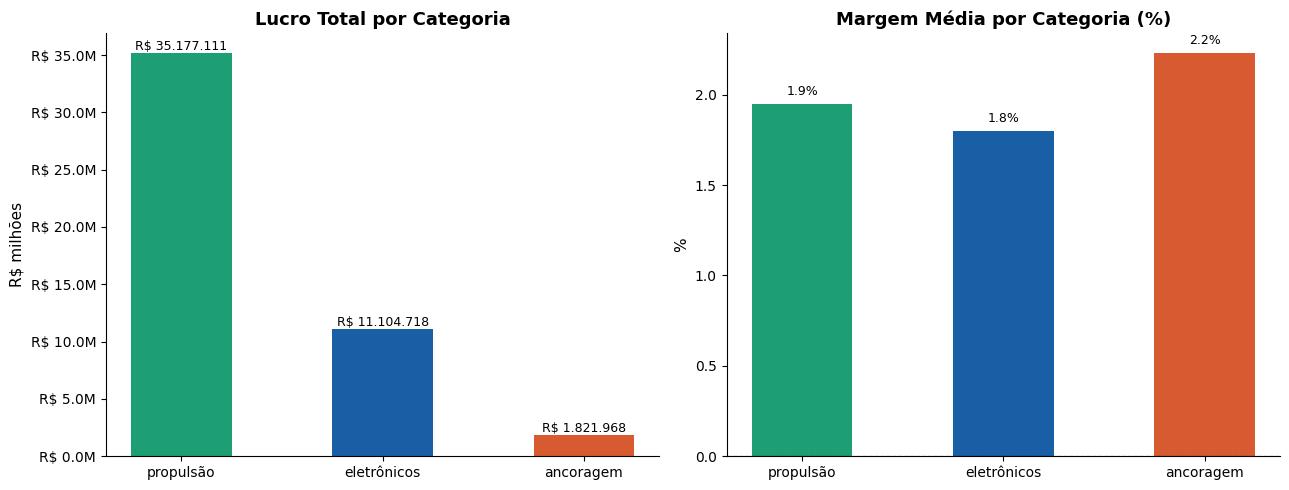

In [84]:
cat = df_analitico.groupby("actual_category").agg(
    lucro  = ("lucro_total", "sum"),
    margem = ("margem_pct",  "mean"),
).round(2).sort_values("lucro", ascending=False)

cores_cat = [COR_LUCRO, COR_NEUTRA, COR_PREJ]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(cat.index, cat["lucro"] / 1e6,
                   color=cores_cat, edgecolor="none", width=0.5)
axes[0].set_title("Lucro Total por Categoria")
axes[0].set_ylabel("R$ milhões")
axes[0].yaxis.set_major_formatter(mt.FuncFormatter(fmt_milhoes))
for bar, val in zip(bars, cat["lucro"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val / 1e6 + 0.3,
                 fmt_brl(val), ha="center", fontsize=9)

bars2 = axes[1].bar(cat.index, cat["margem"],
                    color=cores_cat, edgecolor="none", width=0.5)
axes[1].set_title("Margem Média por Categoria (%)")
axes[1].set_ylabel("%")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars2, cat["margem"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                 f"{val:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Análise 5 — Top 10 clientes por lucro gerado

Os 10 principais clientes concentram parcela significativa do lucro total,
reforçando a importância de estratégias de retenção para esse grupo.

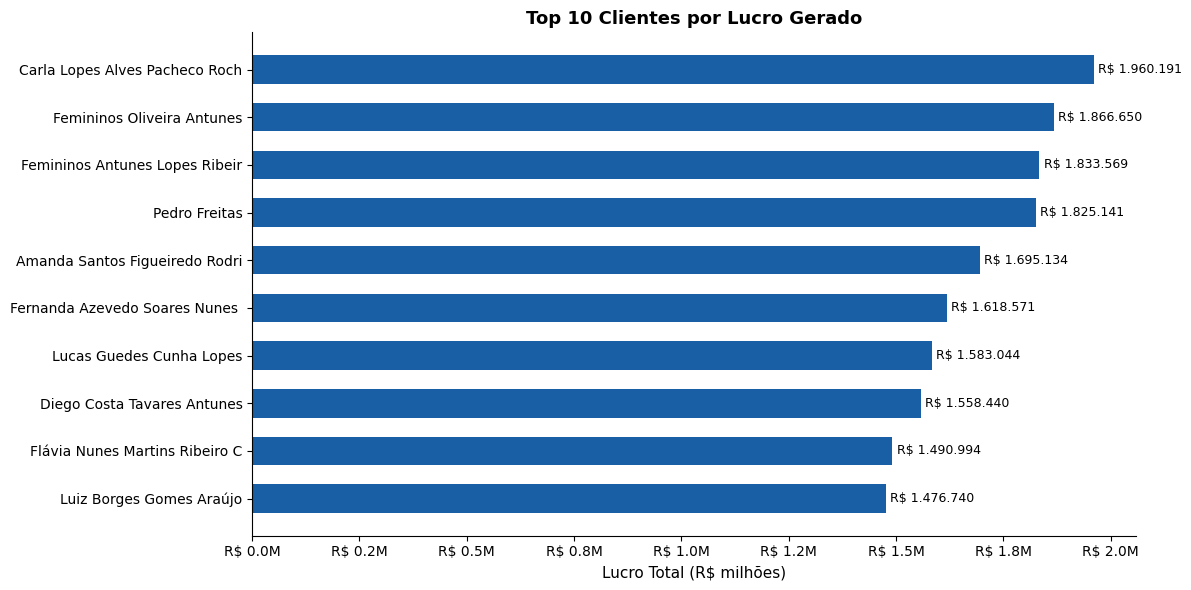

In [86]:
top_clientes = (
    df_analitico.groupby("full_name")["lucro_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_clientes.index.str[:30],
    top_clientes.values / 1e6,
    color=COR_NEUTRA, edgecolor="none", height=0.6
)
ax.set_title("Top 10 Clientes por Lucro Gerado")
ax.set_xlabel("Lucro Total (R$ milhões)")
ax.xaxis.set_major_formatter(mt.FuncFormatter(fmt_milhoes))
for bar, val in zip(bars, top_clientes.values):
    ax.text(val / 1e6 + 0.01, bar.get_y() + bar.get_height() / 2,
            fmt_brl(val), va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Projeção e Simulação de Cenários

Regressão linear aplicada à receita mensal para projetar 2025,
combinada com simulação de impacto cambial na margem.

In [89]:
# preparar série mensal
df_analitico["mes"] = df_analitico["sale_date"].dt.to_period("M")
mensal = df_analitico.groupby("mes").agg(
    receita=("total", "sum")
).reset_index()
mensal["mes_idx"]   = range(len(mensal))
mensal["mes_str"]   = mensal["mes"].astype(str)
mensal["receita_mm3"] = mensal["receita"].rolling(3, min_periods=1).mean()

# treinar modelo
X      = mensal[["mes_idx"]]
modelo = LinearRegression().fit(X, mensal["receita_mm3"])
mensal["tendencia"] = modelo.predict(X)
r2     = r2_score(mensal["receita_mm3"], mensal["tendencia"])

# projetar 2025
X_2025    = pd.DataFrame({"mes_idx": range(24, 36)})
proj_2025 = modelo.predict(X_2025)
meses_2025 = [str(p) for p in pd.period_range("2025-01", periods=12, freq="M")]

print(f"Crescimento mensal estimado: R$ {modelo.coef_[0]:,.0f}")
print(f"R²: {r2:.3f}")
print(f"Receita total projetada 2025: R$ {proj_2025.sum():,.0f}")

Crescimento mensal estimado: R$ 757,134
R²: 0.383
Receita total projetada 2025: R$ 1,534,860,127


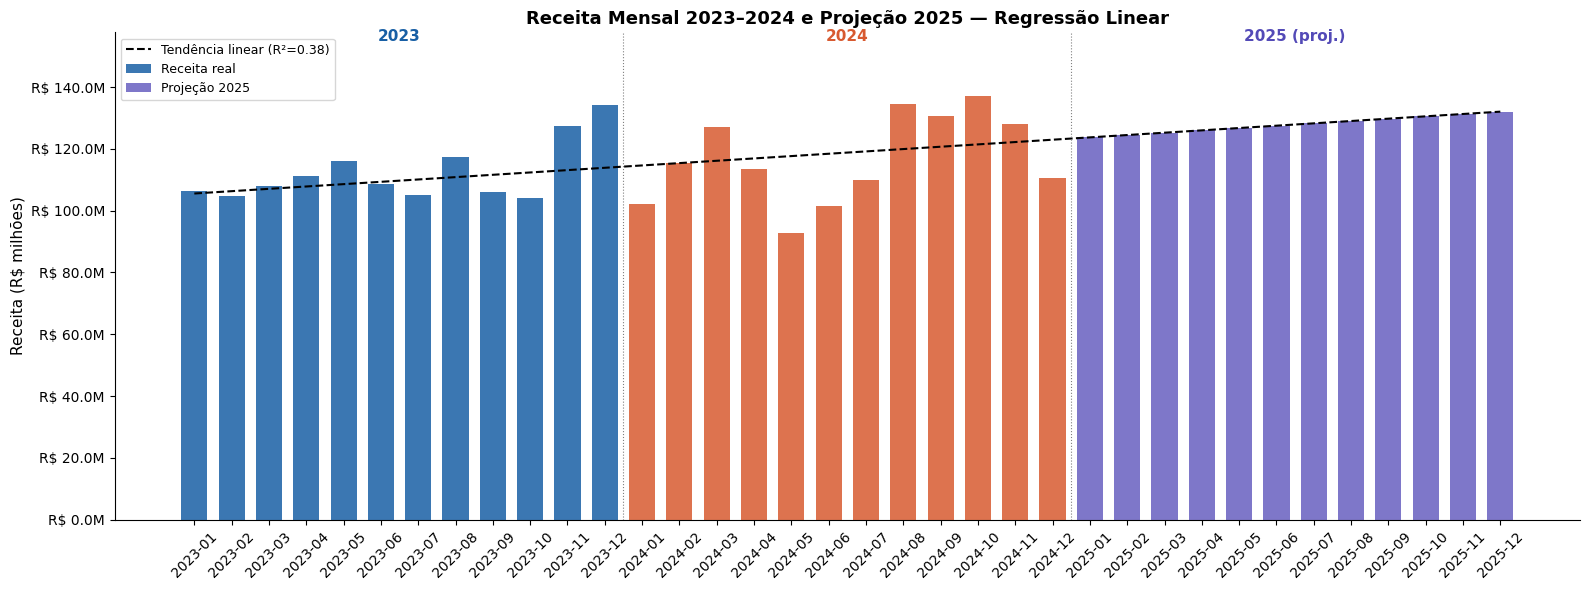

In [91]:
fig, ax = plt.subplots(figsize=(16, 6))

cores = ["#185FA5"] * 12 + ["#D85A30"] * 12
ax.bar(mensal["mes_str"], mensal["receita"] / 1e6,
       color=cores, edgecolor="none", width=0.7, alpha=0.85, label="Receita real")

ax.bar(meses_2025, proj_2025 / 1e6,
       color="#534AB7", edgecolor="none", width=0.7, alpha=0.75, label="Projeção 2025")

todos_x = pd.DataFrame({"mes_idx": range(36)})
tendencia_completa = modelo.predict(todos_x)
todos_labels = list(mensal["mes_str"]) + meses_2025
ax.plot(todos_labels, tendencia_completa / 1e6,
        color="black", linewidth=1.5, linestyle="--",
        label=f"Tendência linear (R²={r2:.2f})")

ax.axvline(x=11.5, color="gray", linewidth=0.8, linestyle=":")
ax.axvline(x=23.5, color="gray", linewidth=0.8, linestyle=":")
ax.text(5.5,  155, "2023",         ha="center", fontsize=11, color="#185FA5", fontweight="bold")
ax.text(17.5, 155, "2024",         ha="center", fontsize=11, color="#D85A30", fontweight="bold")
ax.text(29.5, 155, "2025 (proj.)", ha="center", fontsize=11, color="#534AB7", fontweight="bold")

ax.set_title("Receita Mensal 2023–2024 e Projeção 2025 — Regressão Linear")
ax.set_ylabel("Receita (R$ milhões)")
ax.yaxis.set_major_formatter(mt.FuncFormatter(fmt_milhoes))
ax.xaxis.set_tick_params(rotation=45)
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, mensal["receita"].max() / 1e6 * 1.15)

plt.tight_layout()
plt.show()

## simulação de cenários de câmbio

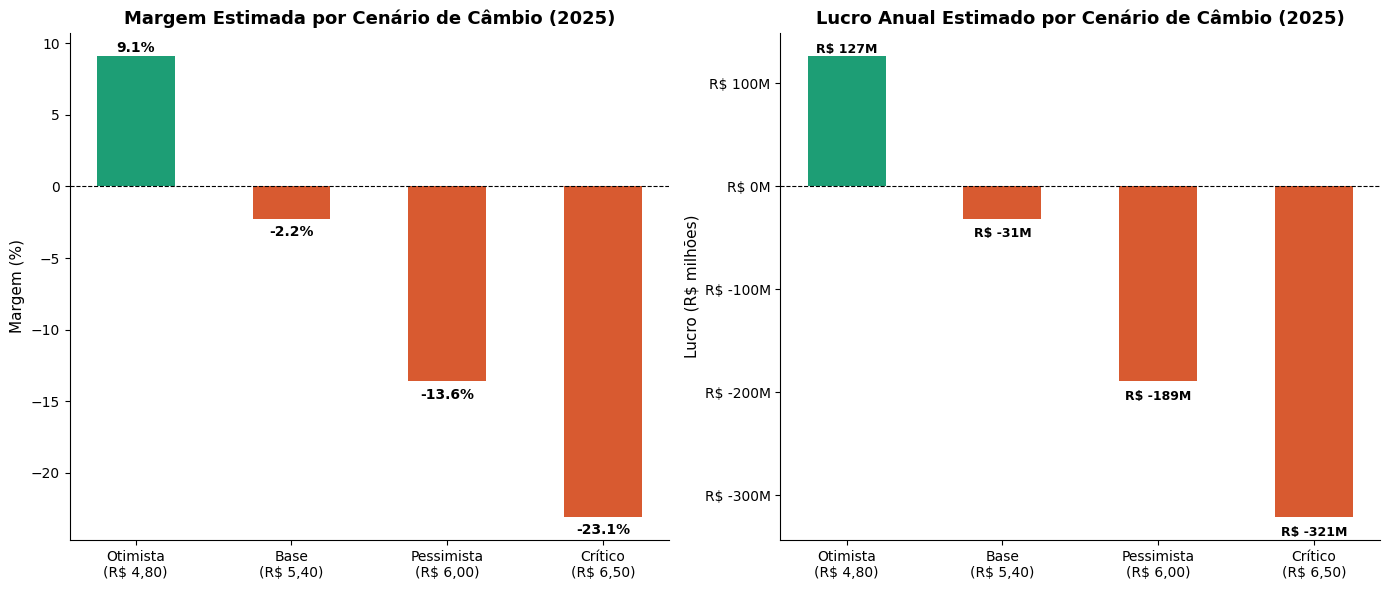

In [93]:
receita_unit_media = df_analitico["preco_unitario"].mean()
usd_price_medio    = df_analitico["usd_price"].mean()

cenarios = {
    "Otimista\n(R$ 4,80)":   4.80,
    "Base\n(R$ 5,40)":       5.40,
    "Pessimista\n(R$ 6,00)": 6.00,
    "Crítico\n(R$ 6,50)":    6.50,
}

margens, lucros = [], []
for taxa in cenarios.values():
    custo_unit = usd_price_medio * taxa
    m = ((receita_unit_media - custo_unit) / receita_unit_media) * 100
    l = (receita_unit_media - custo_unit) * df_analitico["qtd"].mean() * len(df_analitico) / 2
    margens.append(m)
    lucros.append(l / 1e6)

nomes     = list(cenarios.keys())
cores_cen = [COR_LUCRO if m >= 0 else COR_PREJ for m in margens]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars = axes[0].bar(nomes, margens, color=cores_cen, edgecolor="none", width=0.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Margem Estimada por Cenário de Câmbio (2025)")
axes[0].set_ylabel("Margem (%)")
for bar, val in zip(bars, margens):
    offset = 0.3 if val >= 0 else -1.2
    axes[0].text(bar.get_x() + bar.get_width()/2, val + offset,
                 f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

bars2 = axes[1].bar(nomes, lucros, color=cores_cen, edgecolor="none", width=0.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Lucro Anual Estimado por Cenário de Câmbio (2025)")
axes[1].set_ylabel("Lucro (R$ milhões)")
axes[1].yaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f"R$ {x:.0f}M"))
for bar, val in zip(bars2, lucros):
    offset = 3 if val >= 0 else -18
    axes[1].text(bar.get_x() + bar.get_width()/2, val + offset,
                 f"R$ {val:.0f}M", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## Conclusão

A análise revelou que a empresa cresceu em receita (+4%) de 2023 para 2024,
mas o lucro virou prejuízo de 32 milhões de reais devido à alta do câmbio em reais  ( 4,99 →  5,39).

A projeção de receita para 2025 aponta 1,53 bilhão de Reais (+9% vs 2024),
porém a sustentabilidade do negócio depende diretamente do câmbio:
apenas com dólar abaixo de R $ 5,00 a operação retorna à margem positiva.

## Principais achados:
- Propulsão concentra 74% do lucro total
- Motor Diesel Yanmar Velocity 37HP gerou o maior prejuízo: R$ 8,7 milhões
- Câmbio é o principal fator de risco do negócio — mais que volume de vendas